# Star Dataset Analysis

## Color vs Temperature Analysis


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load The Dataset

In [2]:
df = pd.read_csv("../data/Stars.csv.xls")

## Research Question

Is there a relationship between a star's color and its temperature based on the visible light spectrum?

## First Look

In [3]:
df.head()

,Temperature,L,R,A_M,Color,Spectral_Class,Type
0,3068,0.002400,0.1700,16.12,Red,M,0
1,3042,0.000500,0.1542,16.60,Red,M,0
2,2600,0.000300,0.1020,18.70,Red,M,0
3,2800,0.000200,0.1600,16.65,Red,M,0
4,1939,0.000138,0.1030,20.06,Red,M,0


In [4]:
df.shape

(240, 7)

In [5]:
df.describe()

,Temperature,L,R,A_M,Type
count,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,2.500000
std,9552.425037,179432.244940,517.155763,10.532512,1.711394
min,1939.000000,0.000080,0.008400,-11.920000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,1.000000
50%,5776.000000,0.070500,0.762500,8.313000,2.500000
75%,15055.500000,198050.000000,42.750000,13.697500,4.000000
max,40000.000000,849420.000000,1948.500000,20.060000,5.000000


## Dataset Information

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    str    
 5   Spectral_Class  240 non-null    str    
 6   Type            240 non-null    int64  
dtypes: float64(3), int64(2), str(2)
memory usage: 13.3 KB


## Next Step

We will investigate whether these groups contain fewer samples than usual and determine if the small sample size could explain their unusual behavio.

## Checking for Duplicate Values

In [7]:
colors = df["Color"].value_counts()

## Standardizing Color Names

In [8]:
df["Color"] = df["Color"].replace(
    {
    "Blue-white": "Blue White",
    "Blue white": "Blue White",
    "Blue-White": "Blue White",

    "white": "White",

    "yellowish": "Yellowish",

    "yellow-white": "Yellow White",

    "White-Yellow": "White Yellow",

    "Pale yellow orange": "Pale Yellow Orange",

    "Orange-Red": "Orange Red"
}
)

The color names have been standardized to ensure consistent grouping during the analysis.

In [9]:


temperature = []

for color in colors.index:
    temperature_mean = df[df["Color"] == color]["Temperature"].mean()
    temperature.append({
        "Color": color,
        "Temperature": temperature_mean
    })

temperature = pd.DataFrame(temperature)
    

Converting Colors to Wavelength Order

In [10]:
color_order = {
    "Red": 1,
    "Orange Red": 2,
    "Orange": 3,
    "Pale Yellow Orange": 4,
    "Yellowish": 5,
    "Yellow White": 6,
    "White Yellow": 7,
    "Yellowish White": 8,
    "White": 9,
    "Whitish": 10,
    "Blue White": 11,
    "Blue": 12
}
temperature["Energy Rank"] = temperature["Color"].map(color_order)

<Axes: xlabel='Energy Rank', ylabel='Temperature'>

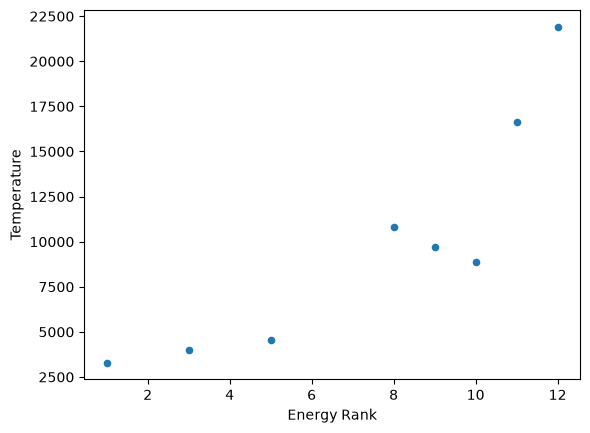

In [18]:
temperature.plot(
    x = "Energy Rank",
    y = "Temperature",
    kind="scatter"
)

Some stars do not follow this expected relationship. We will investigate whether these groups contain fewer samples than usual and determine if the small sample size could explain their unusual behavior.

In [19]:
count = df["Color"].value_counts()
count.loc[count < 10]

Color
Yellow White          8
Yellowish White       3
Yellowish             3
Whitish               2
Orange                2
Pale Yellow Orange    1
White Yellow          1
Orange Red            1
Name: count, dtype: int64

## Conclusion

Therefore, the overall trend remains consistent with the expected relationship between color and temperature.